In [1]:
import json
import csv
import pickle
import numpy as np
from decimal import Decimal, getcontext
import matplotlib.pyplot as plt
import xgi
import importlib 
m = importlib.import_module(".model", "src")
sem = importlib.import_module(".sem", "src") # my implementation of baby SEM
em = importlib.import_module(".em", "src")
ll = importlib.import_module(".likelihoods", "src")
# disgenenet, always encountered devision by 0, something finiky here

plt.style.use('seaborn-v0_8-whitegrid')

def expectation(x):
    
    to_sum = [(i)*j for i,j in enumerate(x)]
      
    return sum(to_sum)

realworld_Hgraphs = ["coauth-dblp", "coauth-mag-geology", "coauth-mag-history", "dawn", "disgenenet",
                     "diseasome", "kaggle-whats-cooking", "ndc-classes", "ndc-substances",
                     "tags-ask-ubuntu", "tags-math-sx" , "tags-stack-overflow", "threads-ask-ubuntu", 
                     "threads-math-sx", "threads-stack-overflow",
                     "congress-bills", "contact-high-school", "contact-primary-school",
                     "email-enron", "email-eu", "hospital-lyon", "hypertext-conference", 
                     "invs13", "invs15",  "malawi-village", "science-gallery", "sfhh-conference"]



num_nodes = ["1,930,378", "1,261,129", "1,034,876", "2,558", "12,368", "516", "6,714", "1,161", "5,556",
            "3,029", "1,629", "49,998", "125,602", "176,445", "2,675,969",
            "1,718", "327", "242", "148", "1,005", "75", "113", "92", "232", "86", "10,972", "403"]

num_edges = ["3,700,681", "1,590,335", "1,812,511", "2,272,433", "2,261", "903", "39,774", "49,726", "112,405",
            "271,233", "822,059", "14,458,875", "192,947", "719,792", "11,305,356",
            "282,049", "172,035", "106,879", "10,885", "235,263", "27,834", "19,036",
            "9,644", "73,822", "99,942", "338,765", "54,305"]

#"dawn"
# "tags-stack-overflow"


num_nodes_dict = dict(zip(realworld_Hgraphs, num_nodes))
num_edges_dict = dict(zip(realworld_Hgraphs, num_edges))


data_type_dict    = {"coauth-dblp": "co-author", 
                     "coauth-mag-geology": "co-author",
                     "coauth-mag-history": "co-author", 
                     "congress-bills": "social", 
                     "contact-high-school": "social",
                     "contact-primary-school": "social",
                     "dawn": "biological",
                     "diseasome": "biological", 
                     "disgenenet": "biological",
                     "email-enron": "social", 
                     "email-eu": "social",
                     "hospital-lyon": "social",
                     "hypertext-conference": "social",
                     "invs13": "social", 
                     "invs15": "social", 
                     "kaggle-whats-cooking": "biological", 
                     "malawi-village": "social",
                     "ndc-classes": "biological",
                     "ndc-substances": "biological", 
                     "science-gallery": "social", 
                     "sfhh-conference": "social",
                     "tags-ask-ubuntu": "webpage", 
                     "tags-math-sx": "webpage",
                     "tags-stack-overflow": "webpage",
                     "threads-ask-ubuntu": "webpage",
                     "threads-math-sx": "webpage", 
                     "threads-stack-overflow": "webpage"}

nontemporal = ["disgenenet", "hypertext-conference", "invs13", "invs15", 
               "kaggle-whats-cooking", "malawi-village", "science-gallery", "sfhh-conference"]
temporal = list(set(realworld_Hgraphs)-set(nontemporal))

mymarkers = ["o", "v","^","<",">","1","2","3","4","s","p","P","*","h","H","+","x","X","D","d"]


data_type_color = {"co-author": "sandybrown", 
                   "social": "cornflowerblue",
                  "biological": "palevioletred",
                  "webpage": "olivedrab"}

data_marker_dict    = {"coauth-dblp": "o", 
                     "coauth-mag-geology": "v",
                     "coauth-mag-history": "^", 
                     "congress-bills": "o", 
                     "contact-high-school": "v",
                     "contact-primary-school": "^",
                     "diseasome": "o", 
                     "dawn": ">",
                     "disgenenet": "1", 
                     "email-enron": "<", 
                     "email-eu": ">",
                     "hospital-lyon": "*",
                     "hypertext-conference": "D",
                     "invs13": "d", 
                     "invs15": "H", 
                     "kaggle-whats-cooking": "v", 
                     "malawi-village": "s",
                     "ndc-classes": "^",
                     "ndc-substances": "<", 
                     "science-gallery": "p", 
                     "sfhh-conference": "P",
                     "tags-ask-ubuntu": "o", 
                     "tags-math-sx": "v",
                     "tags-stack-overflow": "^",
                     "threads-ask-ubuntu": "<",
                     "threads-math-sx": ">", 
                     "threads-stack-overflow": "1"}




C:\Users\hexie\.conda\envs\Hgraph\lib\site-packages\xgi\__init__.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
C:\Users\hexie\.conda\envs\Hgraph\lib\site-packages\xgi\utils\utilities.py:9: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
def normalize(numbers):
    numbers = np.array(numbers, dtype=np.float64)
    total = np.sum(numbers)
    
    normalized = numbers / total
    
    # Renormalize to ensure the sum is exactly 1
    normalized_sum = np.sum(normalized)
    if normalized_sum != 1.0:
        normalized = normalized / normalized_sum
    
    return normalized.tolist()

def get_para(data_name):
    PARA = {}

    with open('sem_results/res_{}.pkl'.format(data_name + "_SEM_new"), "rb") as f:
        d = pickle.load(f)

        
    #print(d["eta"][-1])
    #print(temp_eta)
    PARA["eta"] = np.mean(d["eta"][-50:])
    temp_beta = list(np.mean(d["beta"][-50:], axis=0))
    temp_beta = [int(x*1e8) for x in temp_beta]
    #sum_beta = sum(temp_beta)
    PARA["beta"] = normalize(temp_beta)
    temp_gamma = list(np.mean(d["gamma"][-50:], axis=0))
    temp_gamma = [int(x*1e8) for x in temp_gamma]
    #sum_gamma = sum(temp_gamma)
    PARA["gamma"] = normalize(temp_gamma)  
    
    
    if sum(PARA["beta"]) !=1.0:
        PARA["beta"][0] = PARA["beta"][0] + (1- sum(PARA["beta"]))
    if sum(PARA["gamma"]) !=1.0:
        PARA["gamma"][0] = PARA["gamma"][0] + (1- sum(PARA["gamma"]))
    

    

    return PARA


def grow_recover_graph(name, parameters, timesteps):
    eta = parameters["eta"]
    beta = parameters["beta"]
    gamma = parameters["gamma"]

    H = m.GrowingHypergraph()
    H.add_edge((0, 1))
    H.add_edge((2, 3))

    for _ in range(timesteps):
        e_ = H.sample_edge(eta, gamma, beta, True)
        
    with open('recovered_HG/HG_{}.pkl'.format(data_name), 'wb') as fp:
        pickle.dump(H, fp)
        
    mean_degree = np.mean(list(H.H.degree().values()))
    mean_k = np.mean(list(H.H.edges.size.asdict().values()))
    
    
    return mean_degree, mean_k


def return_mean_stats(data_name):
    
    H0 = xgi.load_xgi_data(data_name)
    
    d1 = np.mean(list(H0.degree().values()))
    k1 = np.mean(list(H0.edges.size.asdict().values()))
    
    timesteps = int(num_edges_dict[data_name].replace(',', ''))
    parameters = get_para(data_name)
    
    d2, k2 = grow_recover_graph(data_name, parameters, timesteps)
    
    return k1, k2, d1, d2


def return_mean_stats_saved(data_name):
    
    H0 = xgi.load_xgi_data(data_name)
    
    d1 = np.mean(list(H0.degree().values()))
    k1 = np.mean(list(H0.edges.size.asdict().values()))
    
    with open('recovered_HG/HG_{}.pkl'.format(data_name), "rb") as f:
        H1 = pickle.load(f)
    
    d2 = np.mean(list(H1.degree().values()))
    k2 = np.mean(list(H1.edges.size.asdict().values()))
    
    return k1, k2, d1, d2

    
def plot_scatter(strings, list1, list2, ax=None):
    if len(strings) != len(list1) or len(strings) != len(list2):
        raise ValueError("All input lists must have the same length")
    
    if ax is None:
        ax = plt.gca()  # Get the current axis if none is provided
    
    x = range(len(strings))  # Create an x-axis based on the index of the strings

    ax.scatter(x, list1, color="cornflowerblue", label='Original')
    ax.scatter(x, list2, color="sandybrown", label='HCM')

    ax.set_xticks(x)
    ax.set_xticklabels(strings, rotation='vertical')
    ax.set_xlabel('Dataset')
    # ax.set_ylabel('Values')
    ax.set_title('Scatter Plot of Two Lists')
    ax.legend()
    
    plt.tight_layout()  # Adjust layout to prevent clipping of tick-labels    



    
    


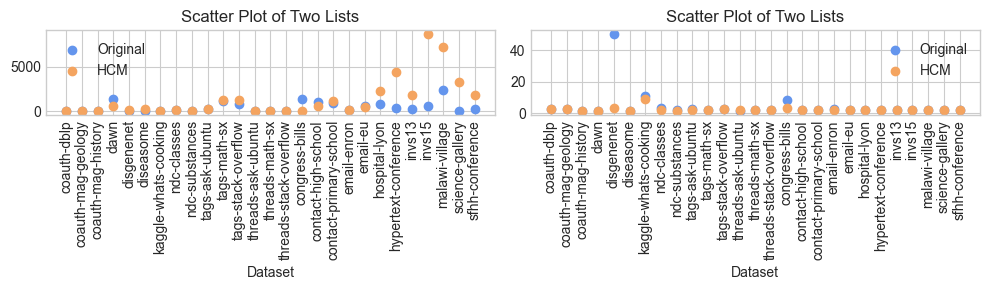

In [16]:

# data_name = "email-enron"

# mean_d1s = []
# mean_k1s = []
# mean_d2s = []
# mean_k2s = []
# datasets = ["email-enron"]

# for data_name in realworld_Hgraphs:
#     # get_para(data_name)
#     k1, k2, d1, d2 = return_mean_stats_saved(data_name)
#     mean_d1s.append(d1)
#     mean_d2s.append(d2)
#     mean_k1s.append(k1)
#     mean_k2s.append(k2)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))


mean_d1s = np.load("mean_d1s.npy")
mean_d2s = np.load("mean_d2s.npy")
mean_k1s = np.load("mean_k1s.npy")
mean_k2s = np.load("mean_k2s.npy")


plot_scatter(realworld_Hgraphs, mean_d1s, mean_d2s, ax=ax[0])
plot_scatter(realworld_Hgraphs, mean_k1s, mean_k2s, ax=ax[1]) 

# #plot mean degree difference

plt.savefig("figures/MEANS.pdf",bbox_inches='tight')


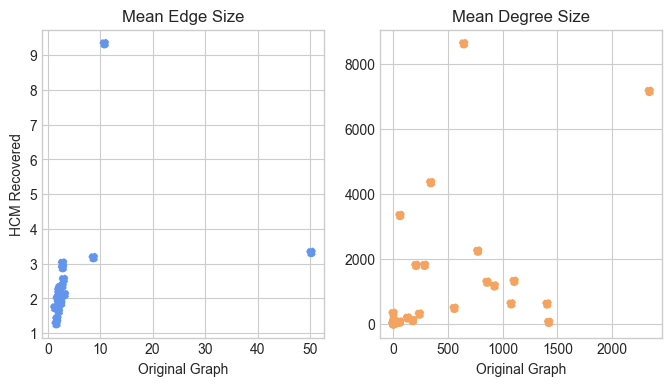

In [13]:


fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

ax[0].scatter(mean_k1s, mean_k2s, color="cornflowerblue", linestyle='--')
ax[0].set_xlabel(r"Original Graph")
ax[0].set_ylabel(r"HCM Recovered")
ax[0].set_title(r"Mean Edge Size")

ax[1].scatter(mean_d1s, mean_d2s, color="sandybrown", linestyle='--')
ax[1].set_xlabel(r"Original Graph")
ax[1].set_title(r"Mean Degree Size")

plt.savefig("figures/MEANS_scatter.pdf",bbox_inches='tight')

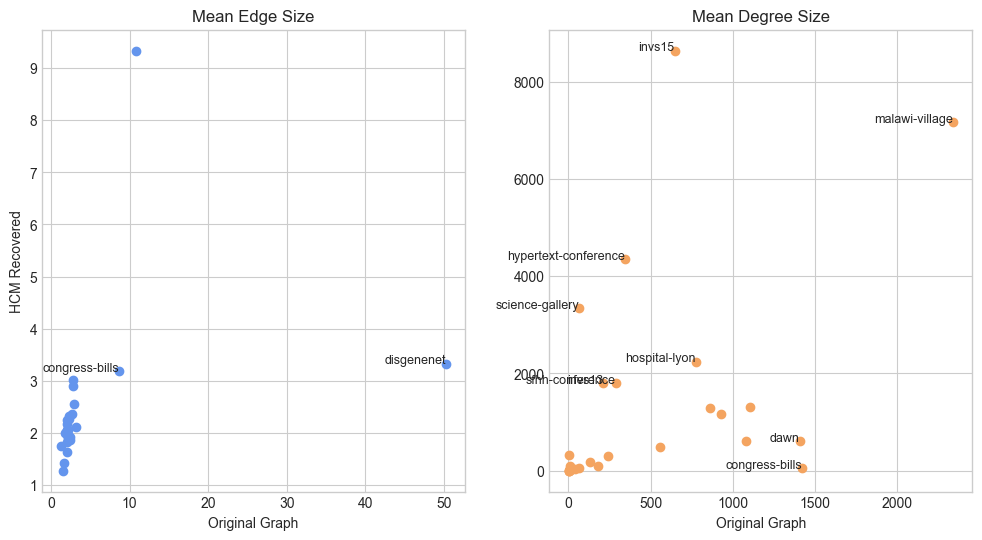

In [24]:
def label_outliers(ax, x, y, labels, threshold):
    distances = np.abs(np.array(x) - np.array(y)) / np.sqrt(2)  # Distance from the diagonal (x=y) line
    for i in range(len(x)):
        if distances[i] > threshold:
            ax.text(x[i], y[i], labels[i], fontsize=9, ha='right')

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))


labels = realworld_Hgraphs
threshold_edge = 3  # Define your outlier threshold
threshold_degree = 500


ax[0].scatter(mean_k1s, mean_k2s, color="cornflowerblue")
ax[0].set_xlabel(r"Original Graph")
ax[0].set_ylabel(r"HCM Recovered")
ax[0].set_title(r"Mean Edge Size")
label_outliers(ax[0], mean_k1s, mean_k2s, labels, threshold_edge)

ax[1].scatter(mean_d1s, mean_d2s, color="sandybrown")
ax[1].set_xlabel(r"Original Graph")
ax[1].set_title(r"Mean Degree Size")
label_outliers(ax[1], mean_d1s, mean_d2s, labels, threshold_degree)

plt.savefig("figures/MEANS_scatter.pdf",bbox_inches='tight')
plt.show()